<a href="https://colab.research.google.com/github/YagoGomesDaSilva/Aprendizado-de-Maquina--Nao-Supervisionado/blob/main/Atividade_III_Unidade_Jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho de Aprendizado de Maquina Não Supervisionado Unidade III

Grupo:
*   Yago Gomes
*   João Maria de Araujo Nogueira Junior
*   Laura Sabrina de Araújo Menezes
*   Mateus Freitas de Oiveira
*   Maria Amanda de Freitas Morais



Base Utilizada:
> [Spotify Tracks Dataset](https://www.kaggle.com/datasets/yashdev01/spotify-tracks-dataset/data)





### Introdução a Problematica:

 O Intuito dessa analise é investigar se os gêneros musicais (Rock, Jazz, Clássica) formam agrupamentos naturais baseados em suas características acústicas, ou se existem "gêneros ocultos" que misturam essas características.

 Para essa analise foi utilizado como base o ***Spotify Tracks Dataset***, disponivel no Kaggle. Essa base foi escolhida por conter milhares de músicas com atributos extraídos pelo Spotify (ex: danceability, energy, acousticness, instrumentalness, tempo).


### Importando a Base:
Primeiramente foi importamos a base para o ambiente de desenvolvimento Jupyter do Colab baseado em python. Ademais, foram importados as bibliotecas dedicadas para aprendizado de maquina do **Scikit Learn** , execute o codigo abaixo para importar a base.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

print("Insira o Spotify Tracks Dataset:")

uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))

    print("\n Dataset Carregado Corretamente:")
    display(df.head(10))


Insira o Spotify Tracks Dataset:


Saving spotify-tracks-dataset.csv to spotify-tracks-dataset.csv
User uploaded file "spotify-tracks-dataset.csv"

 Dataset Carregado Corretamente:


,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
5,5,5,01MVOl9KtVTNfFiBU9I7dc,Tyrone Wells,Days I Will Remember,Days I Will Remember,58,214240,False,0.688,...,-8.807,1,0.1050,0.2890,0.000000,0.1890,0.6660,98.017,4,acoustic
6,6,6,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,74,229400,False,0.407,...,-8.822,1,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,3,acoustic
7,7,7,1EzrEOXmMH3G43AXT1y7pA,Jason Mraz,We Sing. We Dance. We Steal Things.,I'm Yours,80,242946,False,0.703,...,-9.331,1,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,4,acoustic
8,8,8,0IktbUcnAGrvD03AWnz3Q8,Jason Mraz;Colbie Caillat,We Sing. We Dance. We Steal Things.,Lucky,74,189613,False,0.625,...,-8.700,1,0.0369,0.2940,0.000000,0.1510,0.6690,130.088,4,acoustic
9,9,9,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,56,205594,False,0.442,...,-6.770,1,0.0295,0.4260,0.004190,0.0735,0.1960,78.899,4,acoustic


# Análise Exploratória

Número de linhas e colunas do conjunto de dados:

In [2]:
print(df.shape)

(114000, 22)


Contagem, média, desvio padrão, mínimo e máximo das variáveis númericas:

In [3]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


Como o objetivo da análise é classificar os diferentes gêneros, é importante identificar quais gêneros estão disponíveis no conjunto de dados:

In [4]:
df['track_genre'].nunique()

114

In [5]:
df['track_genre'].unique()

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country', 'dance',
       'dancehall', 'death-metal', 'deep-house', 'detroit-techno',
       'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep', 'edm',
       'electro', 'electronic', 'emo', 'folk', 'forro', 'french', 'funk',
       'garage', 'german', 'gospel', 'goth', 'grindcore', 'groove',
       'grunge', 'guitar', 'happy', 'hard-rock', 'hardcore', 'hardstyle',
       'heavy-metal', 'hip-hop', 'honky-tonk', 'house', 'idm', 'indian',
       'indie-pop', 'indie', 'industrial', 'iranian', 'j-dance', 'j-idol',
       'j-pop', 'j-rock', 'jazz', 'k-pop', 'kids', 'latin', 'latino',
       'malay', 'mandopop', 'metal', 'metalcore', 'minimal-techno', 'mpb',
       'new-age', 'opera', 'pagode', 'party', 'piano', 'pop-film', 'pop',
       'pow

Ao analisar a distribuição dos gêneros por meio de um histograma, é possível observar que o dataset apresenta uma quantidade equilibrada de registros para cada gênero musical.

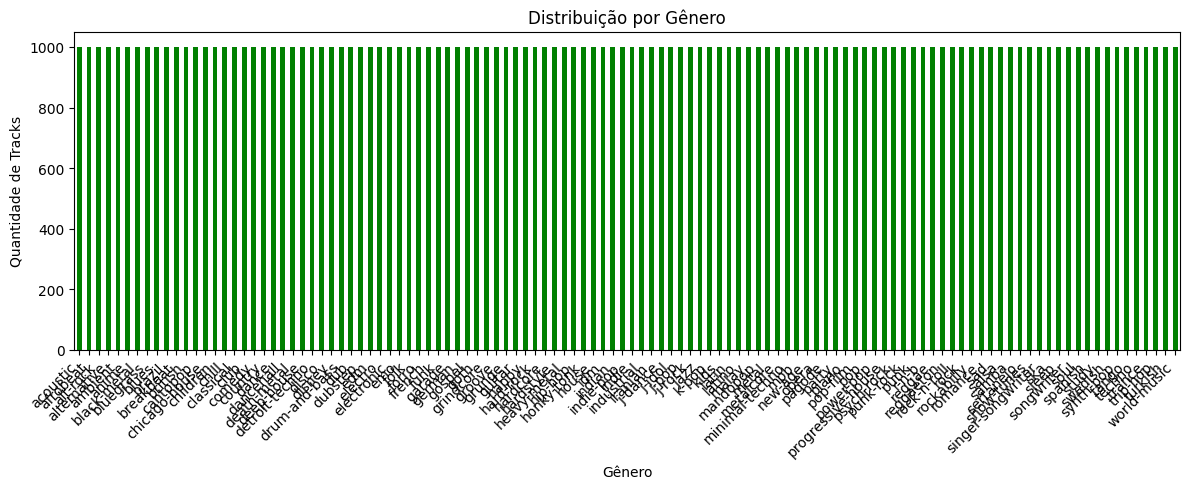

In [6]:
plt.figure(figsize=(12, 5))
df['track_genre'].value_counts().plot(kind='bar', color='green')
plt.title('Distribuição por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Tracks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

A matriz de correlação permite visualizar, lado a lado, as variáveis do conjunto de dados e analisar o grau de relacionamento entre elas. Para essa análise, foram selecionadas apenas as propriedades numéricas do dataset.

No mapa de calor, tons mais intensos de vermelho indicam correlações positivas mais fortes, enquanto tons de azul representam correlações negativas. Quanto mais intensa a cor, maior a magnitude da correlação observada.

Com base na matriz, é possível identificar algumas relações relevantes, como a forte correlação positiva entre as variáveis *loudness* e *energy*, bem como entre *valence* e *danceability*. Essas correlações sugerem que músicas mais energéticas tendem a apresentar maior volume percebido, enquanto músicas com características mais positivas tendem a ser mais dançantes.


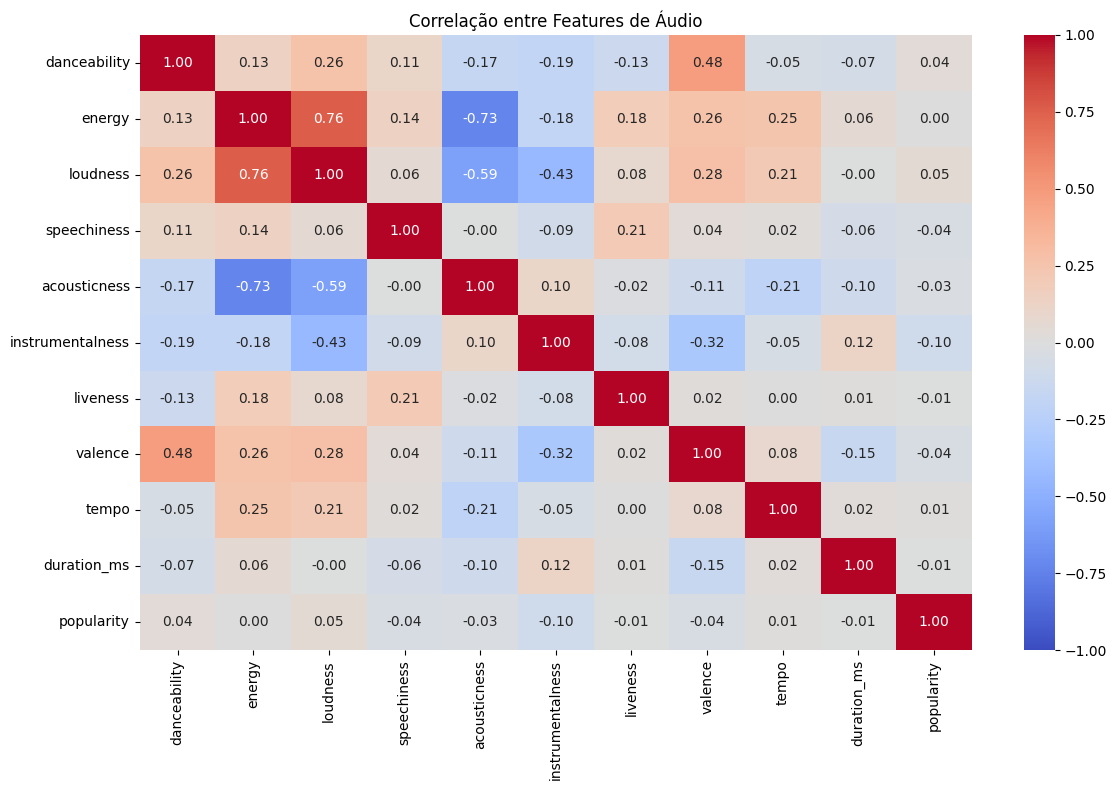

In [7]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness',
                  'valence', 'tempo', 'duration_ms', 'popularity']

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[audio_features].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1
)
plt.title('Correlação entre Features de Áudio')
plt.tight_layout()
plt.show()

# Redução de Dimensionalidade

Para esta análise, foram aplicadas três técnicas de redução de dimensionalidade, com o objetivo de representar os dados em um espaço de menor dimensão, preservando ao máximo suas características originais e facilitando a visualização dos agrupamentos.

- **PCA (Principal Component Analysis):** técnica linear de redução de dimensionalidade que transforma os atributos originais em novos componentes não correlacionados entre si. Esses componentes são organizados de forma a preservar a maior parte da variância presente nos dados.

- **t-SNE (t-Distributed Stochastic Neighbor Embedding):** técnica não linear baseada em distribuições probabilísticas, amplamente utilizada para visualização de dados em baixa dimensão. Seu principal objetivo é preservar relações de proximidade entre amostras, mantendo pontos semelhantes próximos uns dos outros.

- **UMAP (Uniform Manifold Approximation and Projection):** técnica não linear que busca preservar tanto a estrutura local quanto a estrutura global dos dados. Além de apresentar bom desempenho computacional, é bastante utilizada para visualização e análise de agrupamentos em conjuntos de dados de alta dimensionalidade.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


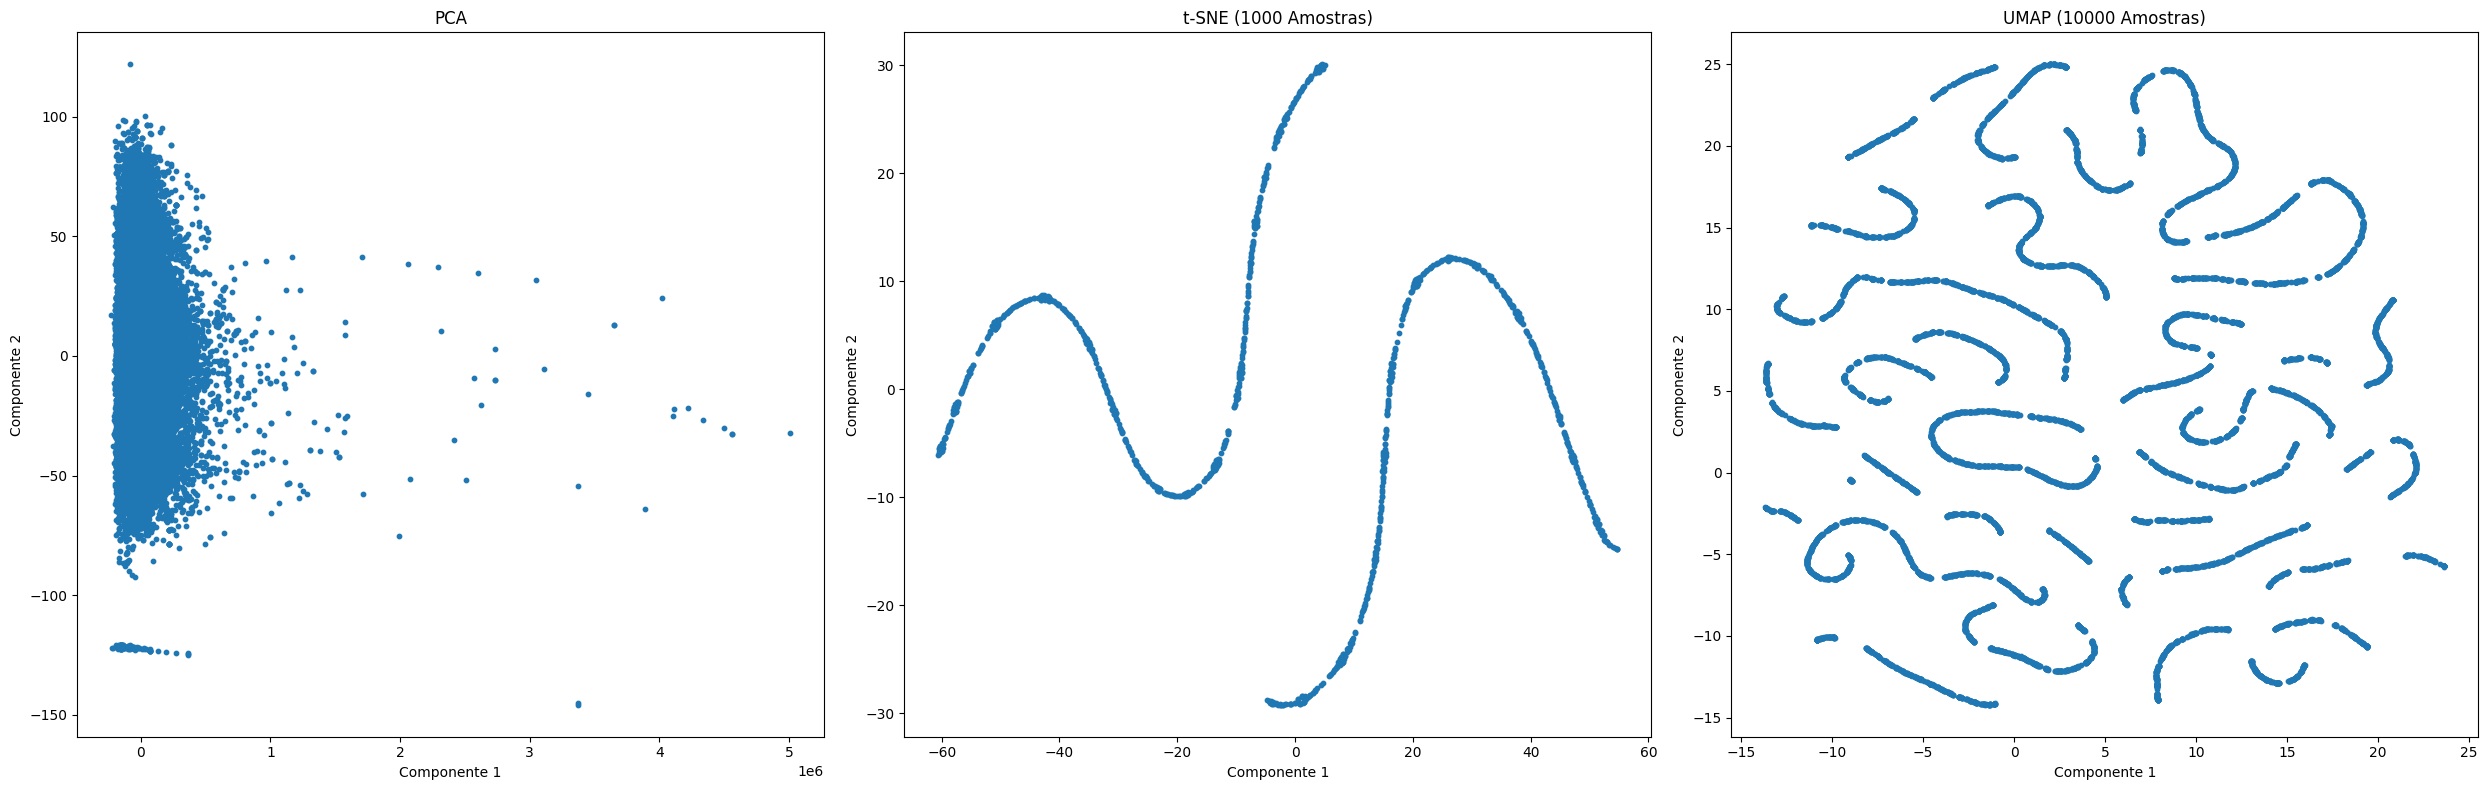

In [15]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

parametros_PCA = {'n_components': 2,'random_state': 42}
parametros_tSNE = {'n_components': 2,'random_state': 42}
parametros_UMAP = {'n_components': 2,'random_state': 42}

# Dataset Apenas com Features Relevantes para a Analise
X = df[audio_features]

def plot_2D_graph(data, title, ax, labels=None):
    if labels is None:
        ax.scatter(data[:, 0], data[:, 1], s=10)
    else:
        scatter = ax.scatter(data[:, 0], data[:, 1], c=labels, cmap='tab10', s=10)
        plt.colorbar(scatter, ax=ax, label='Cluster')

    ax.set_title(title)
    ax.set_xlabel('Componente 1')
    ax.set_ylabel('Componente 2')


fig, axes = plt.subplots(1, 3, figsize=(25, 8))

# PCA
pca_df = PCA(**parametros_PCA).fit_transform(X)

plot_2D_graph(pca_df, 'PCA', axes[0])

# t-SNE
sample_size = 1000
X_tsne_sample = X.sample(n=sample_size, random_state=42) if len(X) > sample_size else X
tsne_df = TSNE(**parametros_tSNE).fit_transform(X_tsne_sample)

plot_2D_graph(tsne_df, 't-SNE (1000 Amostras)', axes[1])

# UMAP
sample_size = 10000
X_umap_sample = X.sample(n=sample_size, random_state=42) if len(X) > sample_size else X
umap_df = umap.UMAP(**parametros_UMAP).fit_transform(X_umap_sample)

plot_2D_graph(umap_df, f'UMAP ({sample_size} Amostras)', axes[2])

plt.tight_layout()
plt.show()

# Clusterização